# 🚗 Driver Drowsiness Detection — TensorFlow
**Binary classification: Alert vs Drowsy**

### Three models compared:
1. **Baseline CNN** — simple 3-block reference model
2. **Advanced CNN** — BatchNorm + GAP + L2 regularisation
3. **MobileNetV2** — transfer learning with 2-phase fine-tuning

### Pipeline:
1. Extract frames from videos using OpenCV
2. Train all 3 models with augmentation + callbacks
3. Evaluate and compare with full metrics + graphs

## 0. Install Dependencies

In [1]:
# Install all required libraries
# torch / torchvision : deep learning framework and pretrained models
# opencv-python       : video reading and image processing
# matplotlib / seaborn: plotting training curves and evaluation charts
# scikit-learn        : confusion matrix, AUC-ROC, class weights
!pip install torch torchvision opencv-python matplotlib seaborn scikit-learn Pillow -q

## 1. Imports and Configuration

In [3]:
import os, time, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models as tv_models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# Use GPU if available, otherwise fall back to CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version :', torch.__version__)
print('Device          :', DEVICE)

# ── Directory paths ───────────────────────────────────────────────────────────
BASE_DIR   = Path('.')
FRAMES_DIR = BASE_DIR / 'dataset' / 'frames'   # Extracted frame images
SAVED_DIR  = BASE_DIR / 'saved_models'          # Trained model weights (.pt)
EVAL_DIR   = BASE_DIR / 'evaluation_plots'      # Saved plots

for d in [SAVED_DIR, EVAL_DIR,
          FRAMES_DIR / 'alert', FRAMES_DIR / 'drowsy']:
    d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE   = 96      # Input image size (96x96 pixels)
CLASSES    = ['alert', 'drowsy']  # Must match subfolder names
BATCH_SIZE = 64      # Images per gradient update
EPOCHS     = 20      # Max epochs (early stopping usually ends sooner)
SEED       = 42      # For reproducibility
VAL_SPLIT  = 0.2     # 20% held out for validation
TARGET_FPS = 5       # Frames per second to extract from videos

# Set seeds for reproducible results across all libraries
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f'\nImage size  : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Max epochs  : {EPOCHS}')
print(f'Classes     : {CLASSES}')

PyTorch version : 2.11.0+cpu
Device          : cpu

Image size  : 96x96
Batch size  : 64
Max epochs  : 20
Classes     : ['alert', 'drowsy']


## 2. Frame Extraction

Place your videos in:
- `dataset/videos/alert/`
- `dataset/videos/drowsy/` (includes drowsy + sleepy footage)

This cell extracts frames at 5fps, rotates portrait videos, converts to grayscale, and saves 96×96 JPEG crops.

In [8]:
def extract_frames(video_path, output_dir, target_fps=5, size=96):
    """
    Extract frames from a video at target_fps.
    Handles portrait video rotation automatically.
    Saves grayscale size×size JPEG images.
    Returns number of frames saved.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f'  [!] Cannot open: {video_path}')
        return 0

    source_fps     = cap.get(cv2.CAP_PROP_FPS) or 30
    frame_interval = max(1, int(source_fps / target_fps))  # Skip interval
    video_name     = Path(video_path).stem
    saved, idx     = 0, 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if idx % frame_interval == 0:
            # Auto-rotate portrait videos filmed on phones
            if frame.shape[0] > frame.shape[1]:
                frame = cv2.rotate(frame, cv2.ROTATE_90_COUNTERCLOCKWISE)

            # Convert BGR → grayscale → resize
            gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (size, size))

            # Save with unique filename encoding video name + frame index
            fname = output_dir / f'{video_name}_f{idx:06d}.jpg'
            cv2.imwrite(str(fname), resized)
            saved += 1
        idx += 1

    cap.release()
    return saved


print('Extracting frames from videos...\n')

for label in CLASSES:
    in_dir  = BASE_DIR / 'dataset' / 'videos' / label
    out_dir = FRAMES_DIR / label
    out_dir.mkdir(parents=True, exist_ok=True)

    if not in_dir.exists():
        print(f'[WARN] {in_dir} not found — skipping.')
        continue

    # Collect all video formats
    video_files = []
    for ext in ['*.mp4', '*.avi', '*.mov', '*.mkv']:
        video_files.extend(in_dir.glob(ext))

    print(f'[{label.upper()}] {len(video_files)} video(s)...')
    total = 0
    for vf in video_files:
        n = extract_frames(vf, out_dir, target_fps=TARGET_FPS, size=IMG_SIZE)
        print(f'  {vf.name}: {n} frames saved')
        total += n
    print(f'  → Subtotal: {total} frames\n')

print('── Class balance ──────────────────────────────────')
for label in CLASSES:
    n = len(list((FRAMES_DIR / label).glob('*.jpg')))
    print(f'  {label:10s}: {n:5d} frames')

Extracting frames from videos...

[ALERT] 19 video(s)...
  alert_01.mp4: 603 frames saved
  alert_02.mp4: 95 frames saved
  alert_03.mp4: 222 frames saved
  alert_04.mp4: 267 frames saved
  alert_05.mp4: 303 frames saved
  alert_06.mp4: 221 frames saved
  alert_07.mp4: 77 frames saved
  alert_08.mp4: 185 frames saved
  alert_09.mp4: 120 frames saved
  alert_10.mp4: 171 frames saved
  alert_11.mp4: 160 frames saved
  alert_12.mp4: 254 frames saved
  alert_13.mp4: 199 frames saved
  alert_14.mp4: 198 frames saved
  alert_15.mp4: 211 frames saved
  alert_16.mp4: 199 frames saved
  alert_17.mp4: 75 frames saved
  alert_18.mp4: 112 frames saved
  alert_19.mp4: 206 frames saved
  → Subtotal: 3878 frames

[DROWSY] 19 video(s)...
  drowsy_01.mp4: 448 frames saved
  drowsy_02.mp4: 202 frames saved
  drowsy_03.mp4: 325 frames saved
  drowsy_04.mp4: 103 frames saved
  drowsy_05.mp4: 204 frames saved
  drowsy_06.mp4: 320 frames saved
  drowsy_07.mp4: 409 frames saved
  drowsy_08.mp4: 200 frames sa

### Preview extracted frames

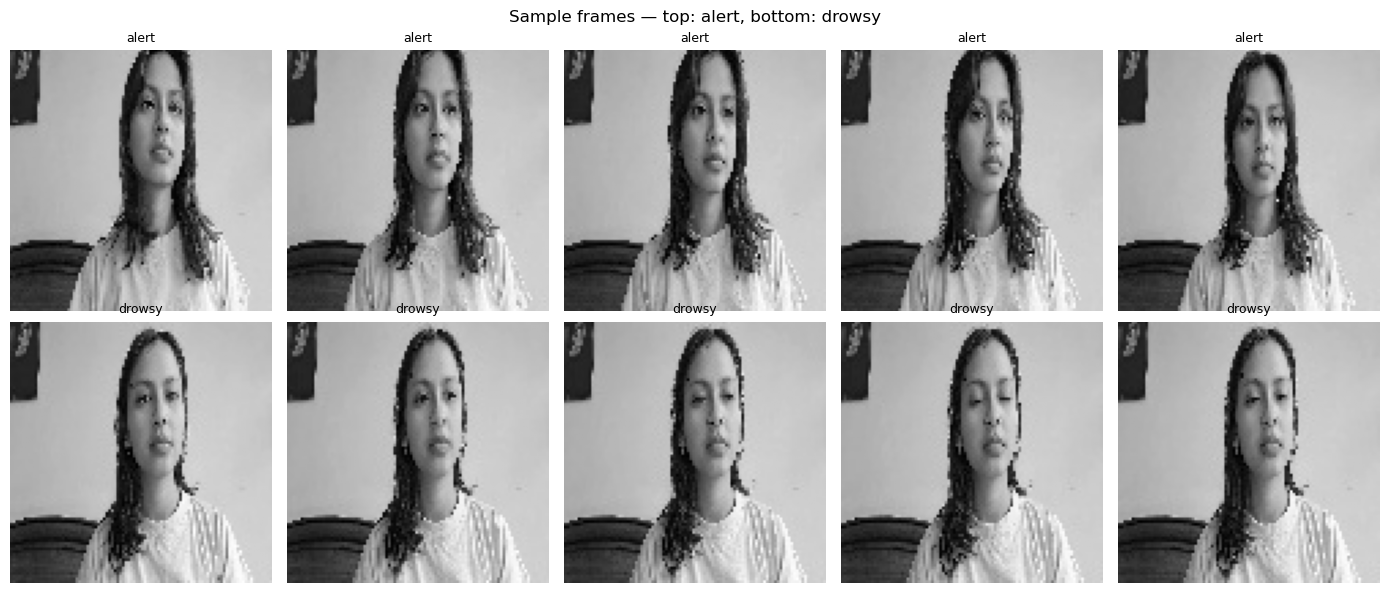

In [11]:
# Show 5 sample frames from each class to verify extraction
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample frames — top: alert, bottom: drowsy', fontsize=12)

for row, label in enumerate(CLASSES):
    imgs = sorted((FRAMES_DIR / label).glob('*.jpg'))[:5]
    for col in range(5):
        ax = axes[row][col]
        if col < len(imgs):
            img = cv2.imread(str(imgs[col]), cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap='gray')
            ax.set_title(label, fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig(str(EVAL_DIR / 'sample_frames.png'), dpi=150)
plt.show()

## 3. Data Generators

In [5]:
# ── Training transform with augmentation ──────────────────────────────────────
# Augmentation increases dataset diversity during training to prevent
# the model from memorising specific images
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),   # Ensure single channel
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),              # Mirror left-right
    transforms.RandomRotation(15),                  # Rotate ±15 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Shift up to 10%
    transforms.ColorJitter(brightness=0.4, contrast=0.3),      # Lighting variation
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)), # Slight zoom
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),   # Normalise to [-1, 1]
])

# ── Validation transform (NO augmentation) ────────────────────────────────────
# Validation images must be clean for fair, consistent evaluation
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Load full dataset with train transforms
# ImageFolder assigns labels alphabetically: alert=0, drowsy=1
full_train_dataset = ImageFolder(root=str(FRAMES_DIR), transform=train_transform)
full_val_dataset   = ImageFolder(root=str(FRAMES_DIR), transform=val_transform)

# Split indices 80/20 into train and val
n_total = len(full_train_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(
    range(n_total), [n_train, n_val], generator=generator
)

# Apply correct transforms to each split
from torch.utils.data import Subset
train_dataset = Subset(full_train_dataset, train_indices.indices)
val_dataset   = Subset(full_val_dataset,   val_indices.indices)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

# ── Class weights for imbalance handling ──────────────────────────────────────
# Computes weights so that misclassifying the minority class
# costs more during training — balances skewed datasets
all_labels = [full_train_dataset.targets[i] for i in train_indices.indices]
cw = compute_class_weight('balanced',
                           classes=np.unique(all_labels),
                           y=all_labels)
# pos_weight: ratio of negative to positive class weight (for BCEWithLogitsLoss)
pos_weight = torch.tensor([cw[1] / cw[0]], dtype=torch.float32).to(DEVICE)

print('Class mapping  :', full_train_dataset.class_to_idx)
print('Class weights  :', cw)
print('pos_weight     :', pos_weight.item())
print('Train samples  :', len(train_dataset))
print('Val samples    :', len(val_dataset))
print('Train batches  :', len(train_loader))
print('Val batches    :', len(val_loader))

Class mapping  : {'alert': 0, 'drowsy': 1}
Class weights  : [0.92357097 1.09021986]
pos_weight     : 1.1804397106170654
Train samples  : 5752
Val samples    : 1437
Train batches  : 90
Val batches    : 23


## 4. Shared Callbacks & Training Timer

In [7]:
# Stores training times and epoch counts for comparison chart
training_times  = {}
epochs_trained  = {}


def train_one_epoch(model, loader, criterion, optimizer):
    """
    One full pass through the training data.
    Returns average loss and accuracy for the epoch.
    """
    model.train()  # Enable dropout and batch norm training mode
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float()  # BCEWithLogitsLoss expects float

        optimizer.zero_grad()                    # Clear previous gradients
        outputs = model(images).squeeze(1)       # Forward pass
        loss    = criterion(outputs, labels)     # Compute loss
        loss.backward()                          # Backpropagate
        optimizer.step()                         # Update weights

        running_loss += loss.item() * images.size(0)
        preds   = (torch.sigmoid(outputs) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()  # Disable gradient computation for validation (faster, less memory)
def validate(model, loader, criterion):
    """
    One full pass through the validation data.
    Returns average loss and accuracy.
    """
    model.eval()  # Disable dropout, use running batch norm statistics
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float()

        outputs = model(images).squeeze(1)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds   = (torch.sigmoid(outputs) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


def train_model(name, model, train_loader, val_loader,
                epochs=EPOCHS, lr=1e-3, weight_decay=0,
                patience_es=10, patience_lr=5):
    """
    Full training loop with:
    - BCEWithLogitsLoss with pos_weight for class imbalance
    - Adam optimiser with optional L2 weight decay
    - ReduceLROnPlateau learning rate scheduler
    - Early stopping based on val accuracy
    - Model checkpointing (saves best weights)
    - Training timer

    Returns history dict with loss/accuracy per epoch.
    """
    print(f'\n{"="*55}')
    print(f'  Training: {name}')
    print(f'{"="*55}')

    model.to(DEVICE)

    # Loss function: BCEWithLogitsLoss combines sigmoid + binary cross-entropy
    # pos_weight corrects for class imbalance
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Adam optimiser; weight_decay adds L2 regularisation penalty
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Reduce LR by half when val_loss stops improving
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=patience_lr, min_lr=1e-7
    )

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    no_improve   = 0
    best_path    = str(SAVED_DIR / f'{name}_best.pt')
    start_time   = time.time()

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = validate(model, val_loader, criterion)
        scheduler.step(v_loss)  # Adjust LR based on validation loss

        history['loss'].append(t_loss)
        history['accuracy'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_accuracy'].append(v_acc)

        print(f'Epoch {epoch:3d}/{epochs}  '
              f'loss={t_loss:.4f}  acc={t_acc:.4f}  '
              f'val_loss={v_loss:.4f}  val_acc={v_acc:.4f}')

        # Save model if validation accuracy improved
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), best_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience_es:
                print(f'  Early stopping at epoch {epoch}.')
                break

    # Restore best weights after training
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    elapsed = time.time() - start_time
    training_times[name] = elapsed
    epochs_trained[name] = len(history['loss'])

    print(f'\n  ✓ {name} done')
    print(f'    Epochs run    : {epochs_trained[name]}')
    print(f'    Best val acc  : {best_val_acc:.4f}')
    print(f'    Training time : {elapsed/60:.1f} min ({elapsed:.0f}s)')

    return history


print('Training utilities ready.')

Training utilities ready.


## 5. Model 1 — Baseline CNN
3 convolutional blocks with Dropout only. Serves as the performance reference.

In [9]:
class BaselineCNN(nn.Module):
    """
    Simple 3-block CNN:
    [Conv → ReLU → MaxPool → Dropout] × 3
    → Flatten → Dense(128) → Dropout → Output

    Regularisation: Dropout only (0.25 spatial, 0.5 dense)
    Output: single logit (BCEWithLogitsLoss applies sigmoid internally)
    """
    def __init__(self, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32 filters — low-level features (edges, textures)
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),      # 96x96 → 48x48
            nn.Dropout2d(0.25),

            # Block 2: 64 filters — mid-level features (eye/mouth shapes)
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),      # 48x48 → 24x24
            nn.Dropout2d(0.25),

            # Block 3: 128 filters — high-level features (open/closed eye patterns)
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),      # 24x24 → 12x12
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                         # 128 × 12 × 12 = 18,432 values
            nn.Linear(128 * 12 * 12, 128), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),                    # Single logit output
        )

    def forward(self, x):
        return self.classifier(self.features(x))


baseline_model = BaselineCNN(in_channels=1)
total_params   = sum(p.numel() for p in baseline_model.parameters())
print(f'Baseline CNN parameters: {total_params:,}')
print(baseline_model)

baseline_history = train_model(
    'baseline_cnn', baseline_model,
    train_loader, val_loader,
    epochs=EPOCHS, lr=1e-3,
    patience_es=10, patience_lr=5,
)

Baseline CNN parameters: 2,452,225
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

  Training: b

In [30]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [32]:
from torchinfo import summary
summary(baseline_model, input_size=(1, 1, 96, 96))

Layer (type:depth-idx)                   Output Shape              Param #
BaselineCNN                              [1, 1]                    --
├─Sequential: 1-1                        [1, 128, 12, 12]          --
│    └─Conv2d: 2-1                       [1, 32, 96, 96]           320
│    └─ReLU: 2-2                         [1, 32, 96, 96]           --
│    └─MaxPool2d: 2-3                    [1, 32, 48, 48]           --
│    └─Dropout2d: 2-4                    [1, 32, 48, 48]           --
│    └─Conv2d: 2-5                       [1, 64, 48, 48]           18,496
│    └─ReLU: 2-6                         [1, 64, 48, 48]           --
│    └─MaxPool2d: 2-7                    [1, 64, 24, 24]           --
│    └─Dropout2d: 2-8                    [1, 64, 24, 24]           --
│    └─Conv2d: 2-9                       [1, 128, 24, 24]          73,856
│    └─ReLU: 2-10                        [1, 128, 24, 24]          --
│    └─MaxPool2d: 2-11                   [1, 128, 12, 12]          --
│    └

## 6. Model 2 — Advanced CNN
Improvements: BatchNorm + L2 regularisation + Global Average Pooling + deeper blocks.

In [11]:
class ConvBnRelu(nn.Module):
    """Building block: Conv2D → BatchNorm → ReLU."""
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__()
        self.block = nn.Sequential(
            # use_bias=False: BatchNorm already handles bias correction
            nn.Conv2d(in_ch, out_ch, kernel, padding=kernel//2, bias=False),
            nn.BatchNorm2d(out_ch),   # Normalise per-channel activations
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class AdvancedCNN(nn.Module):
    """
    4 double-conv blocks with BatchNorm:
    [Conv→BN→ReLU → Conv→BN→ReLU → MaxPool → Dropout] × 4
    → GlobalAveragePooling
    → Dense(256)→BN→ReLU→Dropout(0.5)
    → Dense(128)→BN→ReLU→Dropout(0.4)
    → Output

    Improvements over Baseline:
    - BatchNorm: stabilises training, implicit regulariser
    - L2 weight decay (1e-4) via Adam weight_decay parameter
    - GlobalAveragePooling: far fewer head parameters vs Flatten
    - Deeper architecture for richer feature representations
    """
    def __init__(self, in_channels=1):
        super().__init__()

        # Block 1: 32 filters
        self.block1 = nn.Sequential(
            ConvBnRelu(in_channels, 32), ConvBnRelu(32, 32),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),  # 96→48
        )
        # Block 2: 64 filters
        self.block2 = nn.Sequential(
            ConvBnRelu(32, 64), ConvBnRelu(64, 64),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),  # 48→24
        )
        # Block 3: 128 filters
        self.block3 = nn.Sequential(
            ConvBnRelu(64, 128), ConvBnRelu(128, 128),
            nn.MaxPool2d(2), nn.Dropout2d(0.30),  # 24→12
        )
        # Block 4: 256 filters — no pooling, feeds into GAP
        self.block4 = nn.Sequential(
            ConvBnRelu(128, 256), ConvBnRelu(256, 256),
        )

        # Global Average Pooling: collapses spatial dims to (batch, 256)
        # Dramatically fewer parameters than Flatten
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classification head with BN and Dropout
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(128, 1),   # Single logit output
        )

    def forward(self, x):
        for block in [self.block1, self.block2, self.block3, self.block4]:
            x = block(x)
        return self.head(self.gap(x))


advanced_model = AdvancedCNN(in_channels=1)
total_params   = sum(p.numel() for p in advanced_model.parameters())
print(f'Advanced CNN parameters: {total_params:,}')

advanced_history = train_model(
    'advanced_cnn', advanced_model,
    train_loader, val_loader,
    epochs=EPOCHS, lr=1e-3,
    weight_decay=1e-4,    # L2 regularisation via Adam weight_decay
    patience_es=10, patience_lr=5,
)

Advanced CNN parameters: 1,272,225

  Training: advanced_cnn
Epoch   1/20  loss=0.7376  acc=0.5850  val_loss=0.6103  val_acc=0.7690
Epoch   2/20  loss=0.7145  acc=0.6127  val_loss=0.6207  val_acc=0.7537
Epoch   3/20  loss=0.6808  acc=0.6441  val_loss=0.6091  val_acc=0.6653
Epoch   4/20  loss=0.6499  acc=0.6785  val_loss=0.5896  val_acc=0.6402
Epoch   5/20  loss=0.6051  acc=0.7069  val_loss=0.5113  val_acc=0.7230
Epoch   6/20  loss=0.5490  acc=0.7460  val_loss=0.3627  val_acc=0.9061
Epoch   7/20  loss=0.4804  acc=0.7825  val_loss=0.3365  val_acc=0.9276
Epoch   8/20  loss=0.3950  acc=0.8319  val_loss=0.1539  val_acc=0.9694
Epoch   9/20  loss=0.3098  acc=0.8802  val_loss=0.1082  val_acc=0.9659
Epoch  10/20  loss=0.2297  acc=0.9157  val_loss=0.0768  val_acc=0.9791
Epoch  11/20  loss=0.1593  acc=0.9419  val_loss=0.0260  val_acc=0.9979
Epoch  12/20  loss=0.1413  acc=0.9508  val_loss=0.0274  val_acc=0.9958
Epoch  13/20  loss=0.1164  acc=0.9591  val_loss=0.0266  val_acc=0.9916
Epoch  14/20  lo

In [34]:
# Advanced CNN summary
from torchinfo import summary
summary(advanced_model, input_size=(1, 1, 96, 96))

Layer (type:depth-idx)                   Output Shape              Param #
AdvancedCNN                              [1, 1]                    --
├─Sequential: 1-1                        [1, 32, 48, 48]           --
│    └─ConvBnRelu: 2-1                   [1, 32, 96, 96]           --
│    │    └─Sequential: 3-1              [1, 32, 96, 96]           352
│    └─ConvBnRelu: 2-2                   [1, 32, 96, 96]           --
│    │    └─Sequential: 3-2              [1, 32, 96, 96]           9,280
│    └─MaxPool2d: 2-3                    [1, 32, 48, 48]           --
│    └─Dropout2d: 2-4                    [1, 32, 48, 48]           --
├─Sequential: 1-2                        [1, 64, 24, 24]           --
│    └─ConvBnRelu: 2-5                   [1, 64, 48, 48]           --
│    │    └─Sequential: 3-3              [1, 64, 48, 48]           18,560
│    └─ConvBnRelu: 2-6                   [1, 64, 48, 48]           --
│    │    └─Sequential: 3-4              [1, 64, 48, 48]           36,992
│  

## 7. Model 3 — MobileNetV2 (Transfer Learning)

**Phase 1** — Freeze backbone, train head only (LR=1e-3)  
**Phase 2** — Unfreeze top 6 backbone blocks, fine-tune at LR=1e-5

In [14]:
class MobileNetV2Drowsiness(nn.Module):
    """
    MobileNetV2 backbone (ImageNet pretrained) with custom head.
    Grayscale input is repeated to 3 channels internally.

    Two-phase training:
    Phase 1: backbone frozen, train head only
    Phase 2: unfreeze top layers, fine-tune at very low LR
    """
    def __init__(self, freeze_base=True):
        super().__init__()

        # Load MobileNetV2 with ImageNet pretrained weights
        backbone      = tv_models.mobilenet_v2(
            weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1
        )
        self.features = backbone.features  # Feature extraction backbone

        # Freeze all backbone parameters in Phase 1
        if freeze_base:
            for param in self.features.parameters():
                param.requires_grad = False

        # Global average pooling over spatial dimensions
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Custom classification head replacing ImageNet's 1000-class head
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 128),  nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, 1),    # Single logit output
        )

    def forward(self, x):
        # MobileNetV2 expects 3 channels — repeat grayscale channel 3 times
        x = x.repeat(1, 3, 1, 1)
        x = self.features(x)
        return self.head(self.gap(x))

    def unfreeze_top(self, n=6):
        """Unfreeze the last n backbone blocks for fine-tuning."""
        feature_layers = list(self.features.children())
        freeze_up_to   = len(feature_layers) - n
        for i, layer in enumerate(feature_layers):
            for param in layer.parameters():
                param.requires_grad = (i >= freeze_up_to)
        unfrozen = sum(1 for p in self.features.parameters() if p.requires_grad)
        print(f'  Unfrozen backbone params: {unfrozen}')


mobilenet_model = MobileNetV2Drowsiness(freeze_base=True)
total_params    = sum(p.numel() for p in mobilenet_model.parameters())
trainable       = sum(p.numel() for p in mobilenet_model.parameters() if p.requires_grad)
print(f'MobileNetV2 total params    : {total_params:,}')
print(f'MobileNetV2 trainable params: {trainable:,} (head only in Phase 1)')

PHASE1_EPOCHS = 10
criterion     = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
t_start       = time.time()

# ── Phase 1: train head only (backbone frozen) ────────────────────────────────
print(f'\nPhase 1 — head only ({PHASE1_EPOCHS} epochs max)...')
mobilenet_model.to(DEVICE)

opt_p1   = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_model.parameters()), lr=1e-3
)
sched_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    opt_p1, mode='min', factor=0.5, patience=3, min_lr=1e-7
)

hist_p1   = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
best_acc1, no_imp1 = 0.0, 0
path_p1   = str(SAVED_DIR / 'mobilenet_phase1_best.pt')

for epoch in range(1, PHASE1_EPOCHS + 1):
    tl, ta = train_one_epoch(mobilenet_model, train_loader, criterion, opt_p1)
    vl, va = validate(mobilenet_model, val_loader, criterion)
    sched_p1.step(vl)
    for k, v in zip(['loss','accuracy','val_loss','val_accuracy'], [tl,ta,vl,va]):
        hist_p1[k].append(v)
    print(f'[P1] Epoch {epoch:3d}/{PHASE1_EPOCHS}  loss={tl:.4f}  acc={ta:.4f}  val_loss={vl:.4f}  val_acc={va:.4f}')
    if va > best_acc1:
        best_acc1 = va; torch.save(mobilenet_model.state_dict(), path_p1); no_imp1=0
    else:
        no_imp1 += 1
        if no_imp1 >= 5: print('  Early stopping P1.'); break

mobilenet_model.load_state_dict(torch.load(path_p1, map_location=DEVICE))

# ── Phase 2: fine-tune top backbone layers ────────────────────────────────────
PHASE2_EPOCHS = EPOCHS - PHASE1_EPOCHS
print(f'\nPhase 2 — fine-tuning top layers ({PHASE2_EPOCHS} epochs max)...')
mobilenet_model.unfreeze_top(n=6)  # Unfreeze last 6 backbone blocks

# Very low LR to make careful adjustments to pretrained weights
opt_p2   = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_model.parameters()), lr=1e-5
)
sched_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    opt_p2, mode='min', factor=0.5, patience=4, min_lr=1e-8
)

hist_p2   = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
best_acc2, no_imp2 = 0.0, 0
path_p2   = str(SAVED_DIR / 'mobilenet_v2_best.pt')

for epoch in range(1, PHASE2_EPOCHS + 1):
    tl, ta = train_one_epoch(mobilenet_model, train_loader, criterion, opt_p2)
    vl, va = validate(mobilenet_model, val_loader, criterion)
    sched_p2.step(vl)
    for k, v in zip(['loss','accuracy','val_loss','val_accuracy'], [tl,ta,vl,va]):
        hist_p2[k].append(v)
    print(f'[P2] Epoch {epoch:3d}/{PHASE2_EPOCHS}  loss={tl:.4f}  acc={ta:.4f}  val_loss={vl:.4f}  val_acc={va:.4f}')
    if va > best_acc2:
        best_acc2 = va; torch.save(mobilenet_model.state_dict(), path_p2); no_imp2=0
    else:
        no_imp2 += 1
        if no_imp2 >= 8: print('  Early stopping P2.'); break

mobilenet_model.load_state_dict(torch.load(path_p2, map_location=DEVICE))

# Merge Phase 1 + Phase 2 histories for plotting
mobilenet_history = {k: hist_p1[k] + hist_p2[k] for k in hist_p1}

elapsed = time.time() - t_start
training_times['MobileNetV2'] = elapsed
epochs_trained['MobileNetV2'] = len(mobilenet_history['loss'])

print(f'\n  ✓ MobileNetV2 done')
print(f'    Epochs run    : {epochs_trained["MobileNetV2"]}')
print(f'    Best val acc  : {max(mobilenet_history["val_accuracy"]):.4f}')
print(f'    Training time : {elapsed/60:.1f} min ({elapsed:.0f}s)')

MobileNetV2 total params    : 2,585,601
MobileNetV2 trainable params: 361,729 (head only in Phase 1)

Phase 1 — head only (10 epochs max)...
[P1] Epoch   1/10  loss=0.4331  acc=0.8079  val_loss=0.2690  val_acc=0.8887
[P1] Epoch   2/10  loss=0.2868  acc=0.8837  val_loss=0.2040  val_acc=0.9235
[P1] Epoch   3/10  loss=0.2643  acc=0.8926  val_loss=0.1676  val_acc=0.9457
[P1] Epoch   4/10  loss=0.2332  acc=0.9101  val_loss=0.1412  val_acc=0.9576
[P1] Epoch   5/10  loss=0.2179  acc=0.9171  val_loss=0.1847  val_acc=0.9207
[P1] Epoch   6/10  loss=0.2020  acc=0.9223  val_loss=0.1188  val_acc=0.9555
[P1] Epoch   7/10  loss=0.2003  acc=0.9225  val_loss=0.1445  val_acc=0.9457
[P1] Epoch   8/10  loss=0.1926  acc=0.9270  val_loss=0.1087  val_acc=0.9631
[P1] Epoch   9/10  loss=0.1933  acc=0.9244  val_loss=0.0865  val_acc=0.9743
[P1] Epoch  10/10  loss=0.1739  acc=0.9325  val_loss=0.1036  val_acc=0.9645

Phase 2 — fine-tuning top layers (10 epochs max)...
  Unfrozen backbone params: 48
[P2] Epoch   1/

In [36]:
# MobileNetV2 summary
from torchinfo import summary
summary(mobilenet_model, input_size=(1, 1, 96, 96))

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV2Drowsiness                              [1, 1]                    --
├─Sequential: 1-1                                  [1, 1280, 3, 3]           --
│    └─Conv2dNormActivation: 2-1                   [1, 32, 48, 48]           --
│    │    └─Conv2d: 3-1                            [1, 32, 48, 48]           (864)
│    │    └─BatchNorm2d: 3-2                       [1, 32, 48, 48]           (64)
│    │    └─ReLU6: 3-3                             [1, 32, 48, 48]           --
│    └─InvertedResidual: 2-2                       [1, 16, 48, 48]           --
│    │    └─Sequential: 3-4                        [1, 16, 48, 48]           (896)
│    └─InvertedResidual: 2-3                       [1, 24, 24, 24]           --
│    │    └─Sequential: 3-5                        [1, 24, 24, 24]           (5,136)
│    └─InvertedResidual: 2-4                       [1, 24, 24, 24]           --
│    │    └─Sequential

## 8. Evaluation — Training Curves, Confusion Matrices, ROC Curves

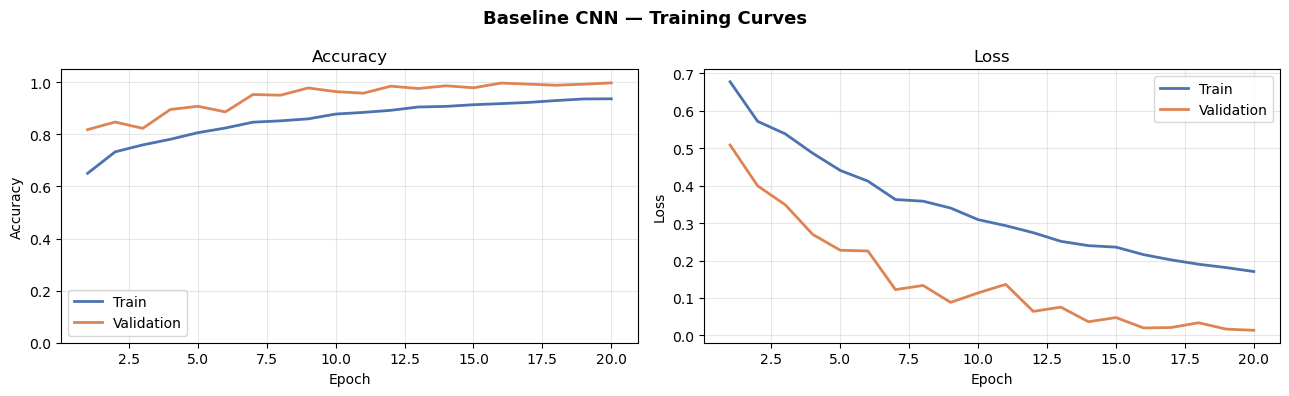

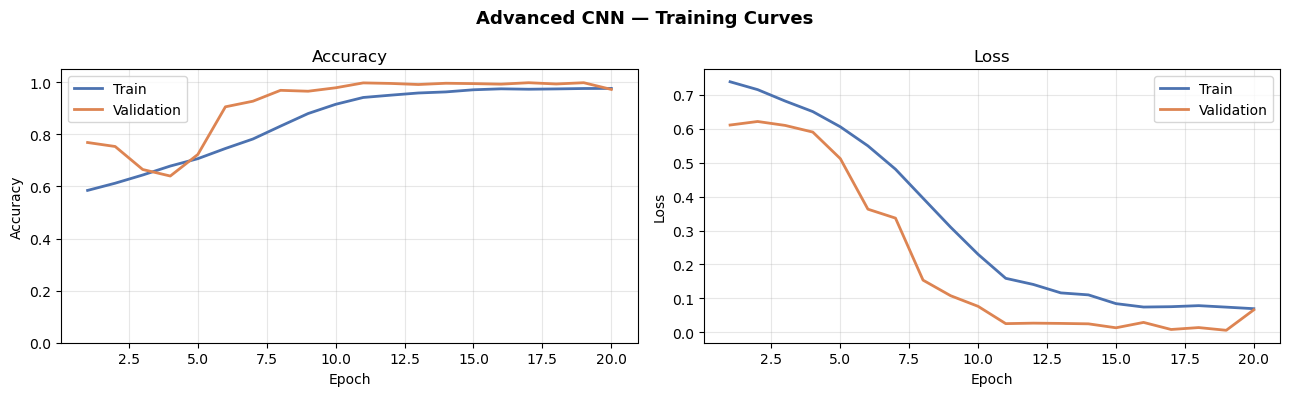

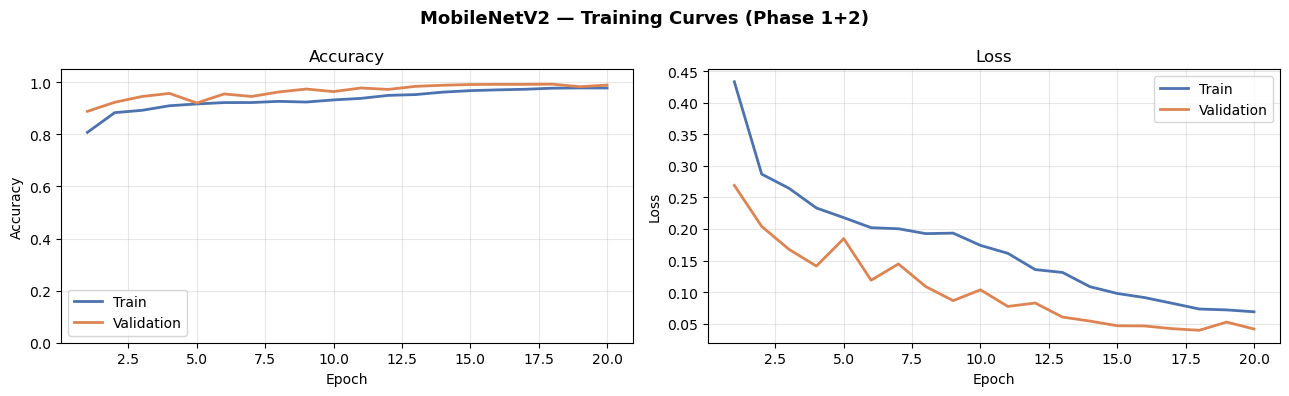


──────────────────────────────────────────────────
  Baseline CNN
  Accuracy : 0.9979    AUC-ROC : 1.0000
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       alert       1.00      1.00      1.00       764
      drowsy       1.00      1.00      1.00       673

    accuracy                           1.00      1437
   macro avg       1.00      1.00      1.00      1437
weighted avg       1.00      1.00      1.00      1437



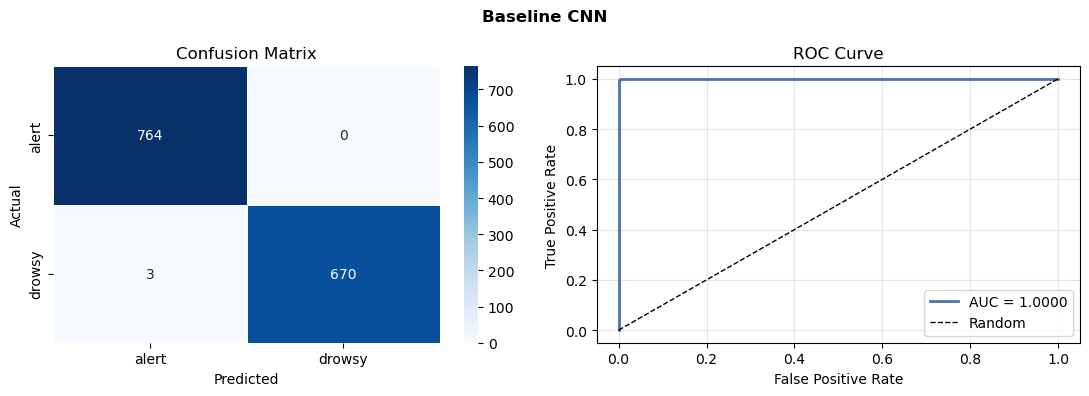


──────────────────────────────────────────────────
  Advanced CNN
  Accuracy : 0.9986    AUC-ROC : 1.0000
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       alert       1.00      1.00      1.00       764
      drowsy       1.00      1.00      1.00       673

    accuracy                           1.00      1437
   macro avg       1.00      1.00      1.00      1437
weighted avg       1.00      1.00      1.00      1437



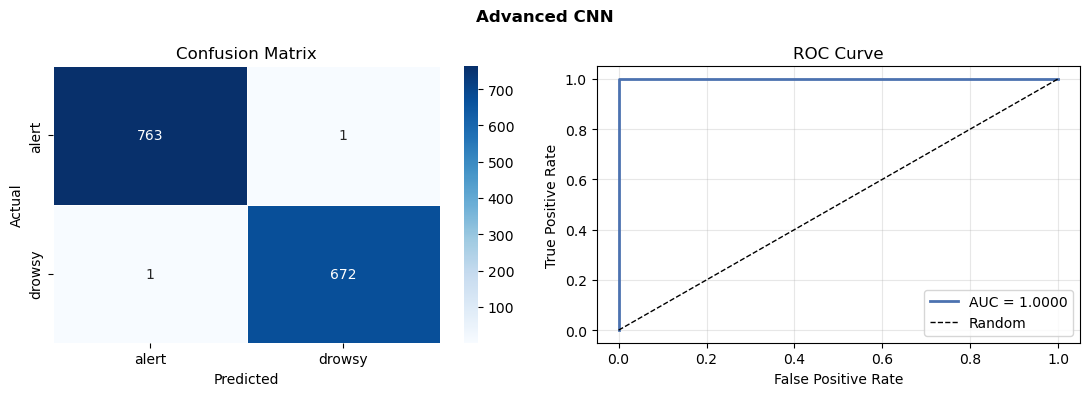


──────────────────────────────────────────────────
  MobileNetV2
  Accuracy : 0.9930    AUC-ROC : 0.9994
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       alert       1.00      0.99      0.99       764
      drowsy       0.99      1.00      0.99       673

    accuracy                           0.99      1437
   macro avg       0.99      0.99      0.99      1437
weighted avg       0.99      0.99      0.99      1437



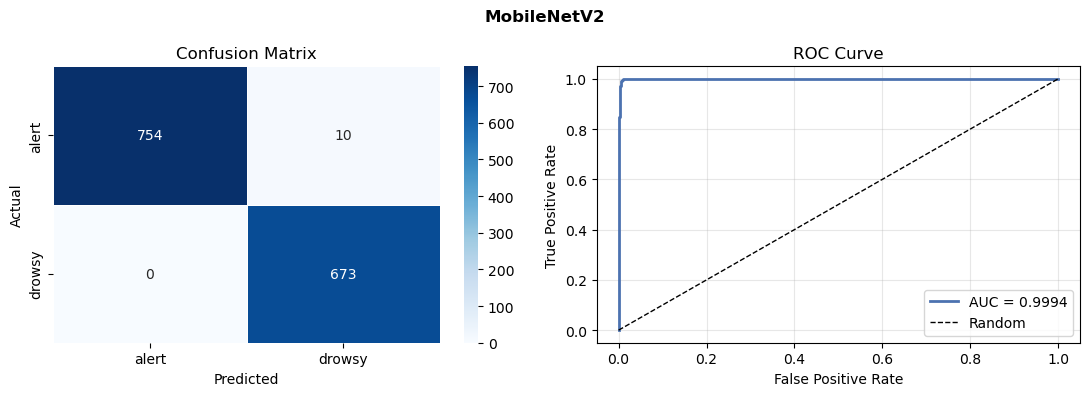

In [17]:
def plot_training_curves(name, history, title=None):
    """
    Plot accuracy and loss curves for train and validation.
    Overfitting shows as val_loss rising while train_loss falls.
    """
    epochs = range(1, len(history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title or name, fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs, history['accuracy'],     label='Train',      color='#4C72B0', lw=2)
    axes[0].plot(epochs, history['val_accuracy'], label='Validation', color='#DD8452', lw=2)
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1.05); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(epochs, history['loss'],     label='Train',      color='#4C72B0', lw=2)
    axes[1].plot(epochs, history['val_loss'], label='Validation', color='#DD8452', lw=2)
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(EVAL_DIR / f'{name}_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()


@torch.no_grad()
def get_predictions(model, loader):
    """Run inference on a DataLoader and return probabilities, predictions, labels."""
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    for images, labels in loader:
        images = images.to(DEVICE)
        logits = model(images).squeeze(1).cpu()
        probs  = torch.sigmoid(logits)           # Convert logits to probabilities
        preds  = (probs >= 0.5).long()           # Threshold at 0.5
        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_preds), np.array(all_labels)


def evaluate_model(name, model, loader, title=None):
    """
    Full evaluation:
    - Accuracy and AUC-ROC score
    - Precision, Recall, F1 per class
    - Confusion matrix heatmap
    - ROC curve
    """
    y_prob, y_pred, y_true = get_predictions(model, loader)

    acc = np.mean(y_pred == y_true)
    auc = roc_auc_score(y_true, y_prob)

    print(f'\n{"─"*50}')
    print(f'  {title or name}')
    print(f'  Accuracy : {acc:.4f}    AUC-ROC : {auc:.4f}')
    print(f'{"─"*50}')
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    # Confusion matrix + ROC curve side by side
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(title or name, fontsize=12, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=axes[0], linewidths=0.5)
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(EVAL_DIR / f'{name}_evaluation.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return acc, auc


# ── Plot training curves ──────────────────────────────────────────────────────
plot_training_curves('baseline_cnn', baseline_history, 'Baseline CNN — Training Curves')
plot_training_curves('advanced_cnn', advanced_history, 'Advanced CNN — Training Curves')
plot_training_curves('mobilenet_v2', mobilenet_history,'MobileNetV2 — Training Curves (Phase 1+2)')

# ── Evaluate each model ───────────────────────────────────────────────────────
results = {}

acc, auc = evaluate_model('baseline_cnn', baseline_model,  val_loader, 'Baseline CNN')
results['Baseline CNN'] = dict(accuracy=acc, auc=auc)

acc, auc = evaluate_model('advanced_cnn', advanced_model,  val_loader, 'Advanced CNN')
results['Advanced CNN'] = dict(accuracy=acc, auc=auc)

acc, auc = evaluate_model('mobilenet_v2', mobilenet_model, val_loader, 'MobileNetV2')
results['MobileNetV2']  = dict(accuracy=acc, auc=auc)

## 9. Final Comparison Charts

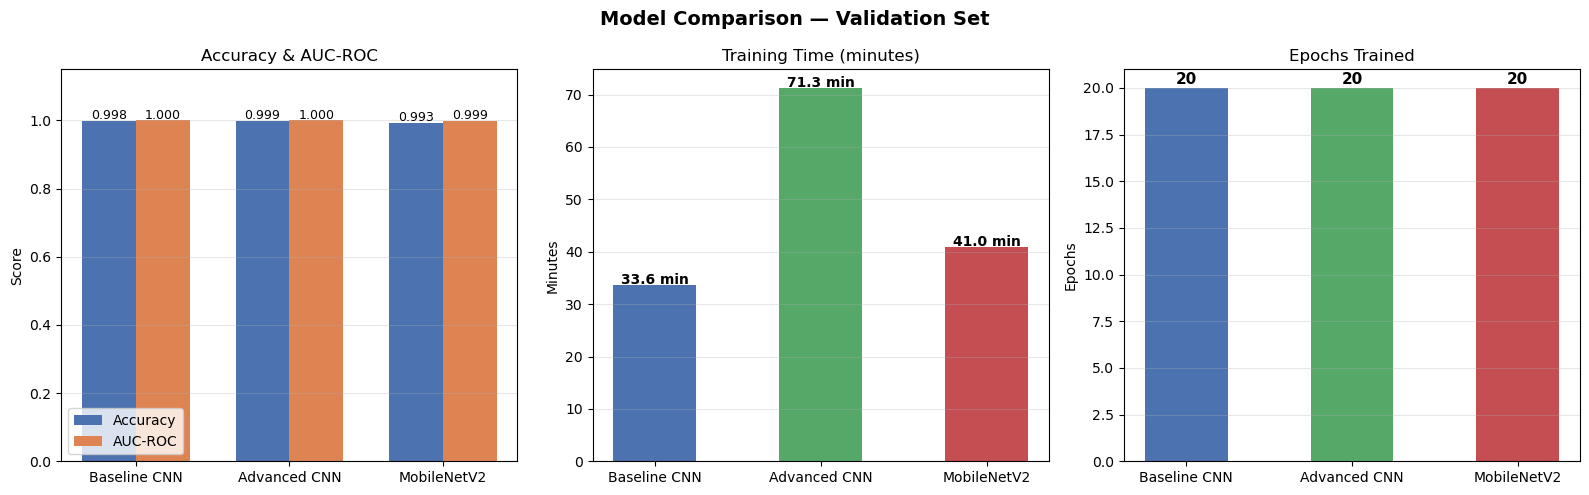

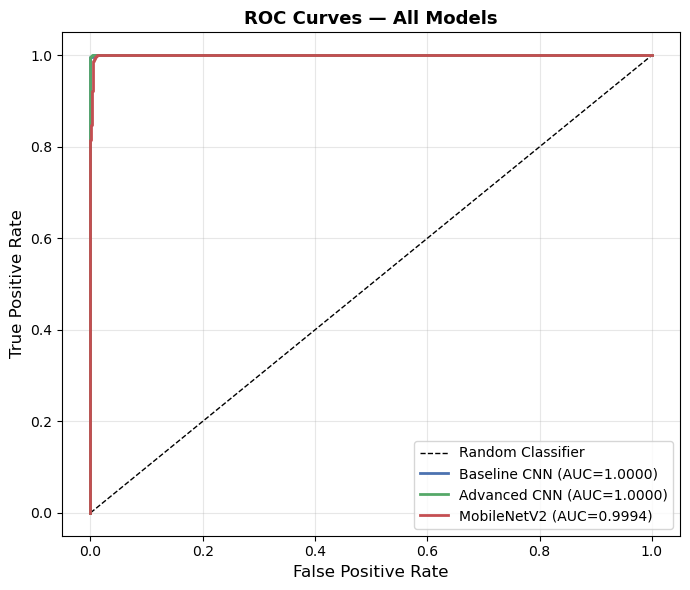


  Model                  Accuracy    AUC-ROC   Epochs       Time
  Baseline CNN             0.9979     1.0000       20      33.6m
  Advanced CNN             0.9986     1.0000       20      71.3m
  MobileNetV2              0.9930     0.9994       20      41.0m

Saved models:
  advanced_cnn_best.pt                          5.1 MB
  baseline_cnn_best.pt                          9.8 MB
  mobilenet_phase1_best.pt                      10.6 MB
  mobilenet_v2_best.pt                          10.6 MB

Evaluation plots saved to: evaluation_plots
Done! 🎉


In [19]:
model_names = list(results.keys())
accs   = [results[n]['accuracy'] for n in model_names]
aucs   = [results[n]['auc']      for n in model_names]
times  = [training_times.get(n, training_times.get(n.lower().replace(' ','_'), 0)) / 60
          for n in model_names]
ep_run = [epochs_trained.get(n, epochs_trained.get(n.lower().replace(' ','_'), 0))
          for n in model_names]

# Fix key lookup for baseline and advanced
time_map   = {'Baseline CNN': 'baseline_cnn', 'Advanced CNN': 'advanced_cnn', 'MobileNetV2': 'MobileNetV2'}
epoch_map  = {'Baseline CNN': 'baseline_cnn', 'Advanced CNN': 'advanced_cnn', 'MobileNetV2': 'MobileNetV2'}
times  = [training_times.get(time_map[n], 0) / 60  for n in model_names]
ep_run = [epochs_trained.get(epoch_map[n], 0)       for n in model_names]

colors = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — Validation Set', fontsize=14, fontweight='bold')

# ── Chart 1: Accuracy & AUC-ROC ───────────────────────────────────────────────
x, w = np.arange(len(model_names)), 0.35
b1 = axes[0].bar(x - w/2, accs, w, label='Accuracy', color='#4C72B0')
b2 = axes[0].bar(x + w/2, aucs, w, label='AUC-ROC',  color='#DD8452')
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
axes[0].set_title('Accuracy & AUC-ROC')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Score')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# ── Chart 2: Training time ────────────────────────────────────────────────────
bars = axes[1].bar(model_names, times, color=colors, width=0.5)
for bar, t in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{t:.1f} min', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Training Time (minutes)')
axes[1].set_ylabel('Minutes'); axes[1].grid(axis='y', alpha=0.3)

# ── Chart 3: Epochs trained ───────────────────────────────────────────────────
bars = axes[2].bar(model_names, ep_run, color=colors, width=0.5)
for bar, ep in zip(bars, ep_run):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 str(ep), ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('Epochs Trained')
axes[2].set_ylabel('Epochs'); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(EVAL_DIR / 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Overlaid ROC curves for all 3 models ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')

for name, color, model in [
    ('Baseline CNN', '#4C72B0', baseline_model),
    ('Advanced CNN', '#55A868', advanced_model),
    ('MobileNetV2',  '#C44E52', mobilenet_model),
]:
    y_prob, _, y_true = get_predictions(model, val_loader)
    fpr, tpr, _       = roc_curve(y_true, y_prob)
    auc_val           = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.4f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(EVAL_DIR / 'roc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary table ───────────────────────────────────────────────────────
print('\n' + '='*62)
print(f'  {"Model":<20} {"Accuracy":>10} {"AUC-ROC":>10} {"Epochs":>8} {"Time":>10}')
print('='*62)
for name, ep, t in zip(model_names, ep_run, times):
    print(f'  {name:<20} '
          f'{results[name]["accuracy"]:>10.4f} '
          f'{results[name]["auc"]:>10.4f} '
          f'{ep:>8} '
          f'{t:>9.1f}m')
print('='*62)

print('\nSaved models:')
for f in sorted(SAVED_DIR.glob('*.pt')):
    print(f'  {f.name:<45} {f.stat().st_size/1e6:.1f} MB')

print('\nEvaluation plots saved to:', EVAL_DIR)
print('Done! 🎉')